In [1]:
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

# 1 - Realised Volatility
### Step 1 & 2
Setting up stooq and a simple plotting function

In [2]:
def download_prices_stooq(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Use yfinance to download daily OHLCV from Stooq.
    PDR is not supported for > python 3.11"""
    
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    candidates = [
       ticker,
       ticker.upper(),
       f"{ticker}.US",
       f"{ticker.upper()}.US",
       f"{ticker}.us",
       f"{ticker.upper()}.us",
    ]

    last_err = None
    for t in candidates:
        try:
            df = yf.download(t, start=start, end=end, progress=False)
            if df is not None and not df.empty:
                return df
        except Exception as e:
            last_err = e

    raise RuntimeError(
        f"Failed to download data for ticker '{ticker}' from Stooq using yfinance."
        f" Tried candidates: {candidates}. Last error: {last_err}"
    )

def plot_stockprice(stock: pd.Series, ticker: str) -> None:
    """Plot the stock price over time."""
    plt.figure(figsize=(12, 6))
    plt.plot(stock.index, stock.values, label=ticker)
    plt.title(f"{ticker} Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


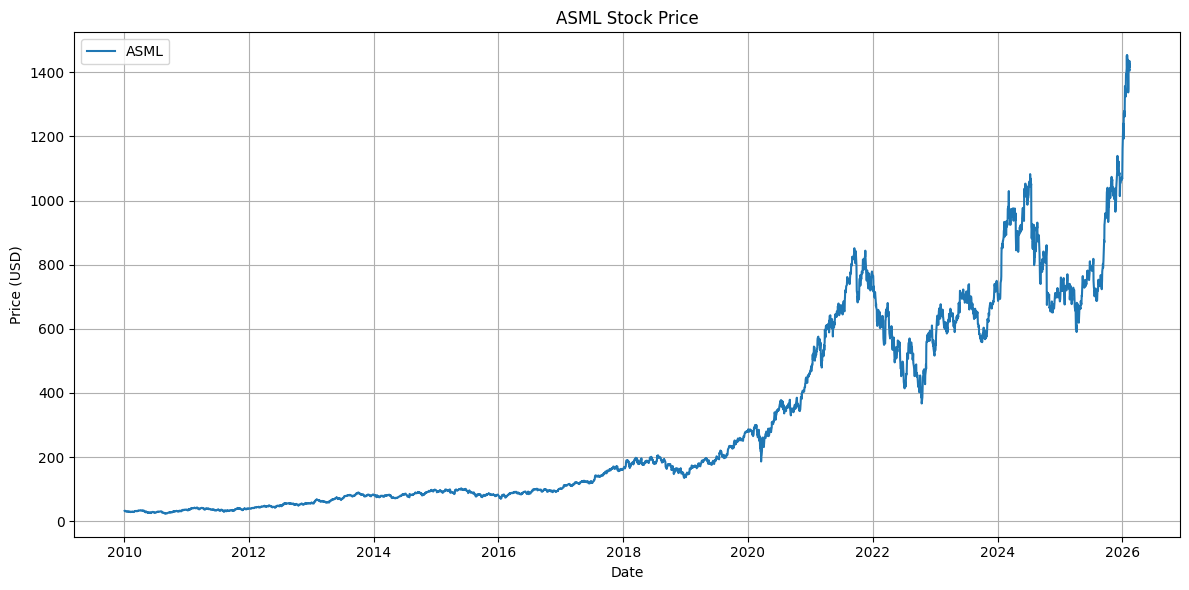

In [3]:
ticker = "ASML"
start_date = "2010-01-01"
end_date = dt.date.today().strftime("%Y-%m-%d")

data = download_prices_stooq(ticker, start_date, end_date)

stock = data["Close"].astype(float)

plot_stockprice(stock, ticker)

### Step 3 - Historical Estimators

In [70]:
def mean_returns(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculates the mean return for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    returns = (stock - stock.shift(1)) / stock.shift(1).dropna()
    # assuming constant dt as 1 -> daily data
    mean_return = returns.rolling(window=window).mean().dropna()

    return mean_return
    

def mean_log_returns(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the mean log return for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    log_returns = np.log(stock / stock.shift(1)).dropna()
    # assuming constant dt as 1 -> daily data
    mean_log_return = log_returns.rolling(window=window).mean()

    return mean_log_return

def historical_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the historical volatility for every entry in the data frame with a rolling window."""
    stock = data["Close"].astype(float)
    returns = stock.pct_change().dropna()
    # assuming constat dt as 1 -> daily data
    sigma = returns.rolling(window=window).std()

    return sigma

def parkinson_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the Parkinson volatility for every entry in the data frame with a rolling window."""
    
    log_hl = np.log(data['High'] / data['Low']).dropna()
    mean = (log_hl**2).rolling(window=window).mean()

    sigma = np.sqrt(mean / (4 * np.log(2)))

    return sigma

def garman_klass_volatility(data: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    """Calculate the Garman-Klass volatility of the stock."""
    log_hl = np.log(data['High'] / data['Low']).dropna()
    log_co = np.log(data['Close'] / data['Open']).dropna()
    
    sigma = np.sqrt(1 / 2 * (log_hl**2).rolling(window=window).mean() - (2 * np.log(2) - 1) * (log_co**2).rolling(window=window).mean())

    return sigma

def plot_metrics(data: pd.DataFrame, ticker: str, window: int = 30) -> None:
    """Plot the stock price, mean return, mean log return, historical volatility, Parkinson volatility and Garman-Klass volatility."""
    stock = data["Close"].astype(float)
    mean_return = mean_returns(data, window=window)
    mean_log_return = mean_log_returns(data, window=window)
    hist_vol = historical_volatility(data, window=window)
    parkinson_vol = parkinson_volatility(data, window=window)
    gk_vol = garman_klass_volatility(data, window=window)

    fig, axs = plt.subplots(3, 1, figsize=(15, 10), dpi=300)
    
    axs[0].plot(stock.index, stock.values, label=ticker)
    axs[0].set_title(f"{ticker} Stock Price")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Price (USD)")
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(mean_return.index, mean_return.values, label="Mean Return")
    axs[1].set_title(f"{ticker} Mean Return (window={window})")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mean Return")
    axs[1].grid()

    axs[1].plot(mean_log_return.index, mean_log_return.values, label="Mean Log Return")
    axs[1].set_title(f"{ticker} Mean Log Return (window={window})")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Mean Log Return")
    axs[1].grid()

    axs[1].set_title(f"{ticker} Returns (window={window})")
    axs[1].legend()
    axs[1].grid()

    axs[2].plot(hist_vol.index, hist_vol.values, label="Historical Volatility")
    axs[2].set_title(f"{ticker} Historical Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Historical Volatility")
    axs[2].grid()

    axs[2].plot(parkinson_vol.index, parkinson_vol.values, label="Parkinson Volatility")
    axs[2].set_title(f"{ticker} Parkinson Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Parkinson Volatility")
    axs[2].grid()

    axs[2].plot(gk_vol.index, gk_vol.values, label="Garman-Klass Volatility")
    axs[2].set_title(f"{ticker} Garman-Klass Volatility (window={window})")
    axs[2].set_xlabel("Date")
    axs[2].set_ylabel("Garman-Klass Volatility")
    axs[2].grid()

    axs[2].set_title(f"{ticker} Volatility Metrics (window={window})")
    axs[2].legend()

    plt.legend()
    plt.tight_layout()
    plt.suptitle(f"{ticker} Stock Metrics", y=1.02)


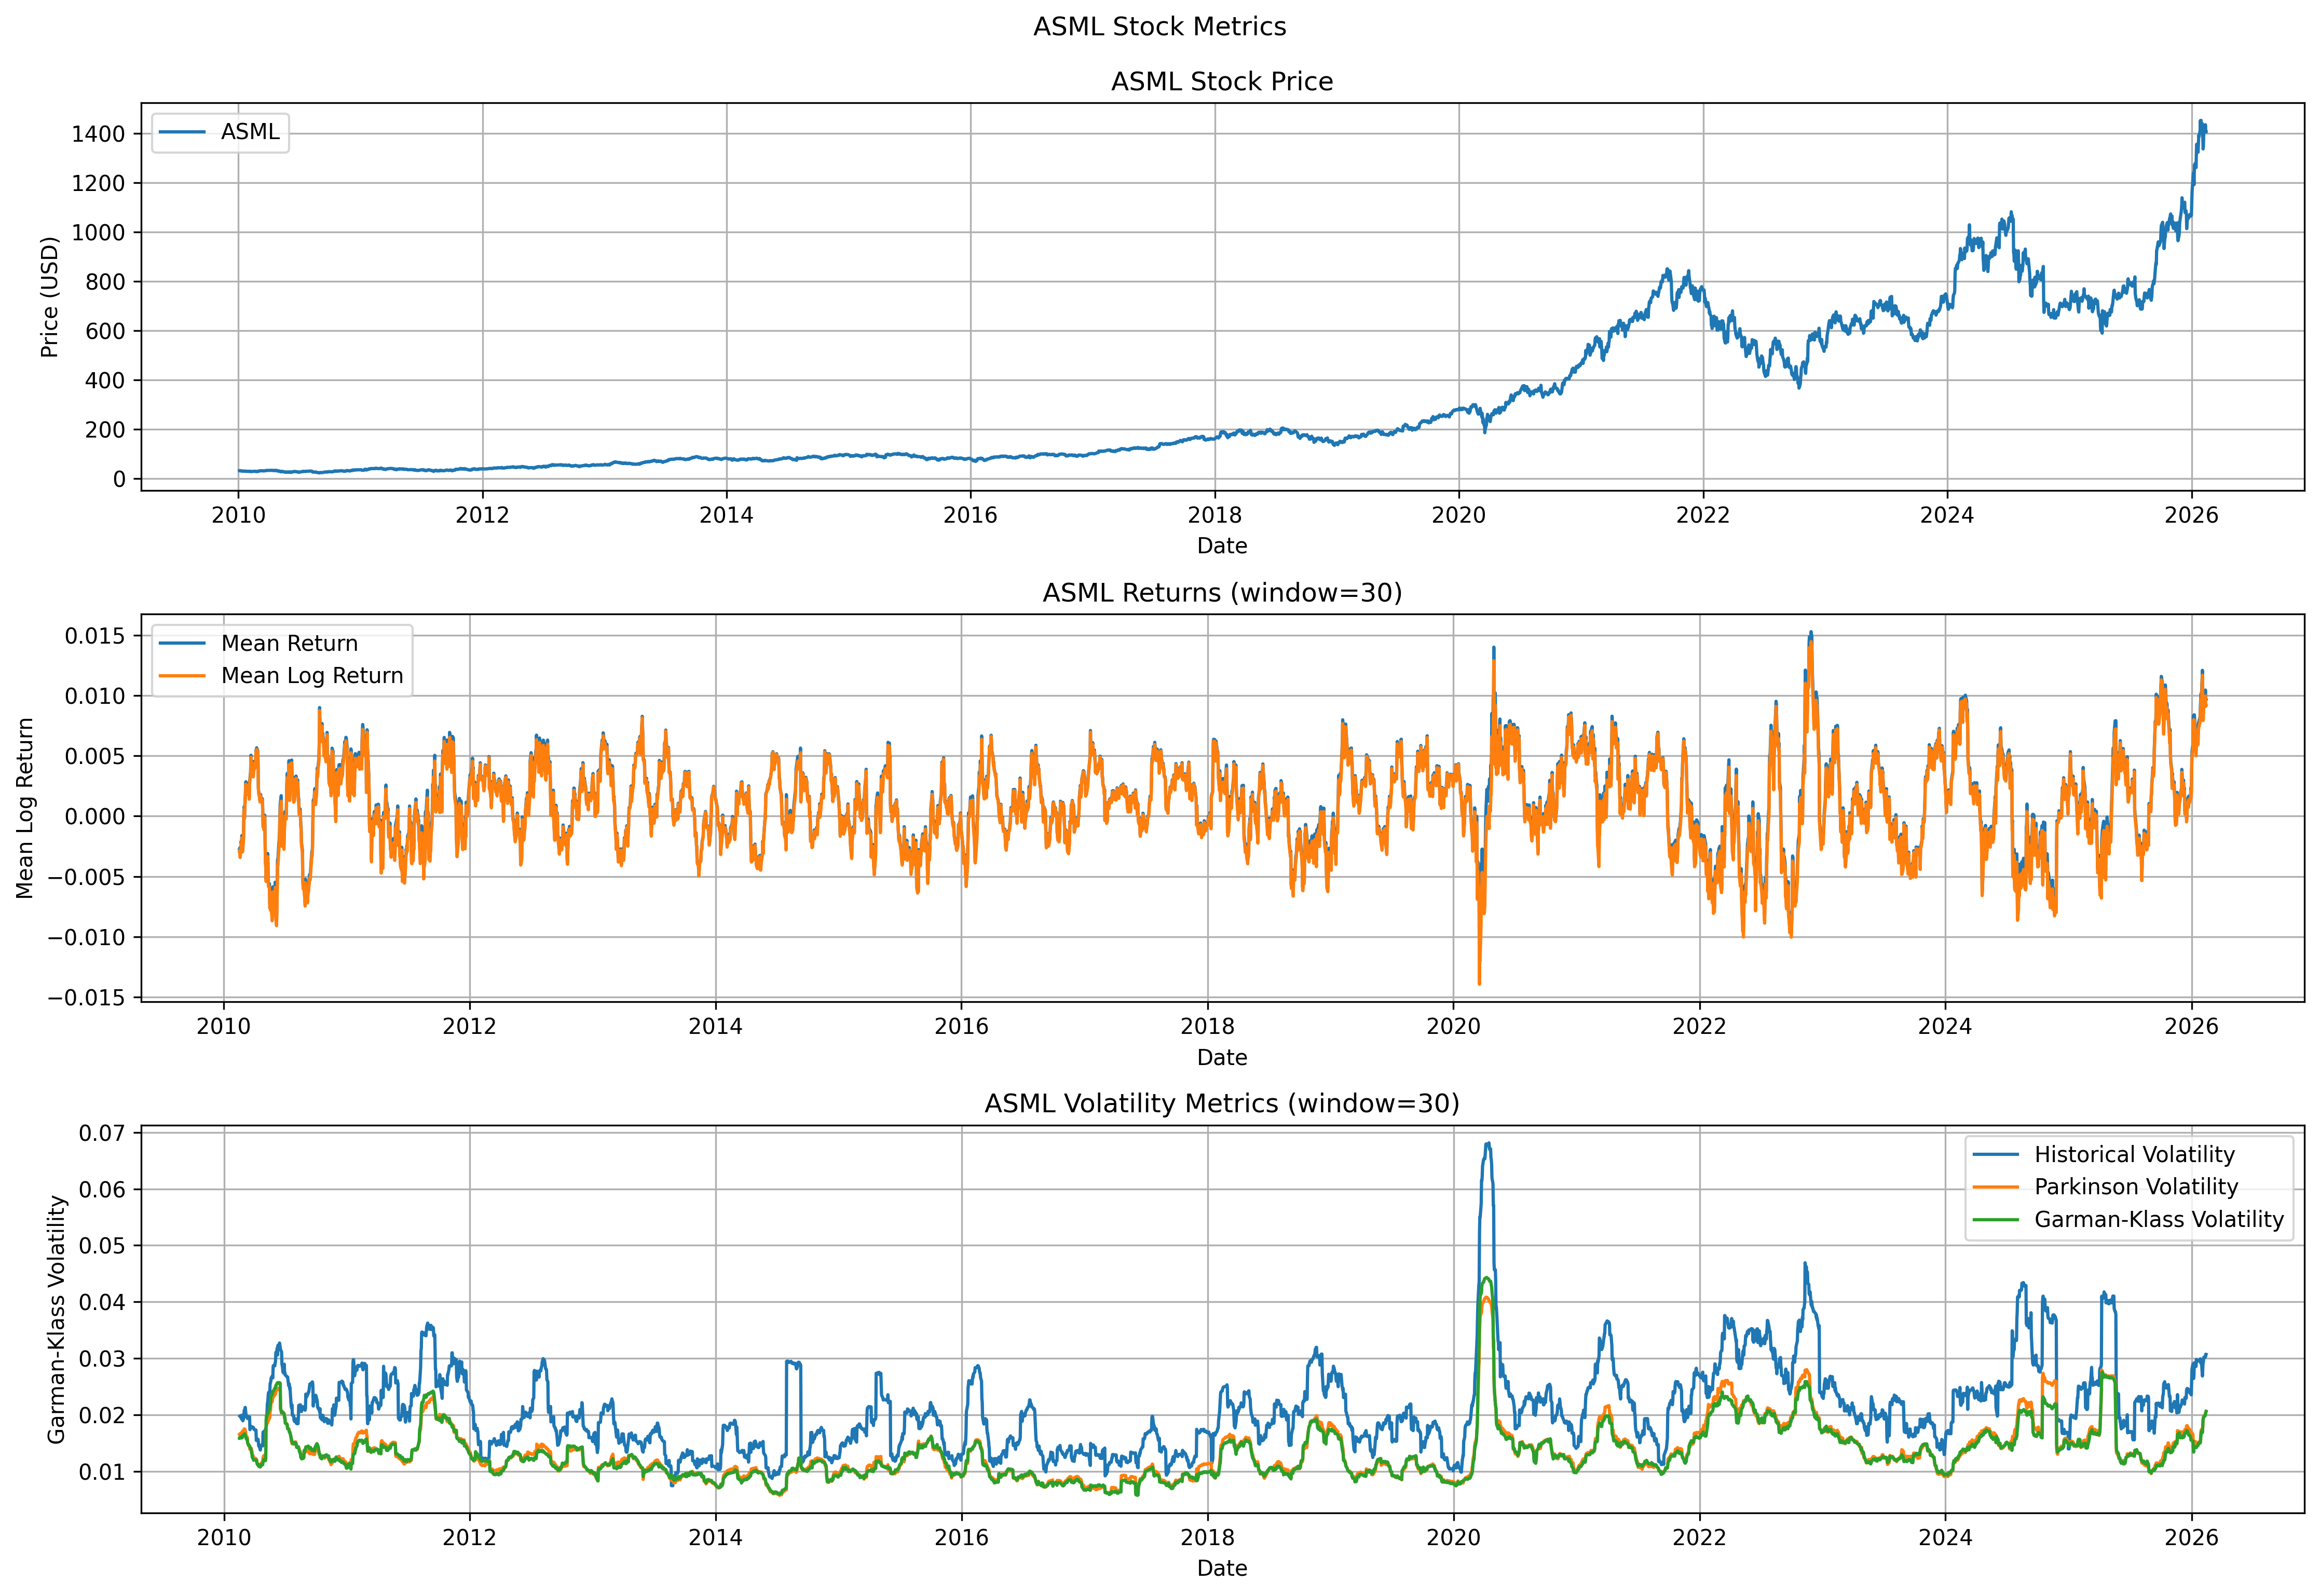

In [71]:
plot_metrics(data, ticker, window=30)